In [1]:
import numpy as np


def generate_nonlinear_data(n_samples=500, random_state=42):
    rng = np.random.default_rng(random_state)

    X = rng.uniform(-5, 5, size=(n_samples, 2))

    radius = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)

    y = (radius < 2.5).astype(int)

    return X, y


In [3]:
x, y = generate_nonlinear_data()

In [8]:
X = x

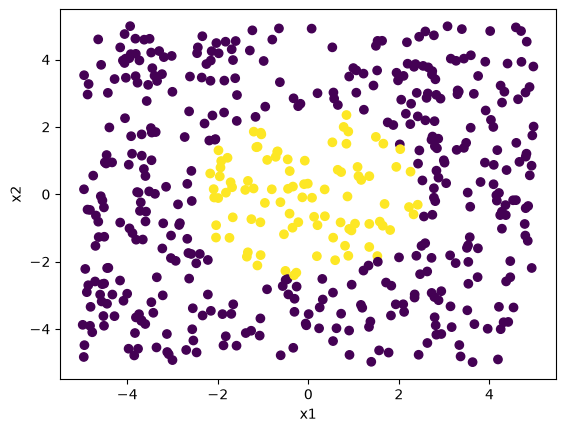

In [16]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")

plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

In [63]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [69]:
poly = PolynomialFeatures(degree=2)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [87]:
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [88]:
poly.get_feature_names_out()

array(['1', 'x0', 'x1', 'x0^2', 'x0 x1', 'x1^2'], dtype=object)

In [89]:
X_train.shape

(335, 6)

In [90]:
from sklearn.linear_model import LogisticRegression

lgr_poly = LogisticRegression()

lgr_poly.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [92]:
y_pred = lgr_poly.predict(X_test)

In [94]:
lgr_poly.score(X_test, y_test)

0.9818181818181818

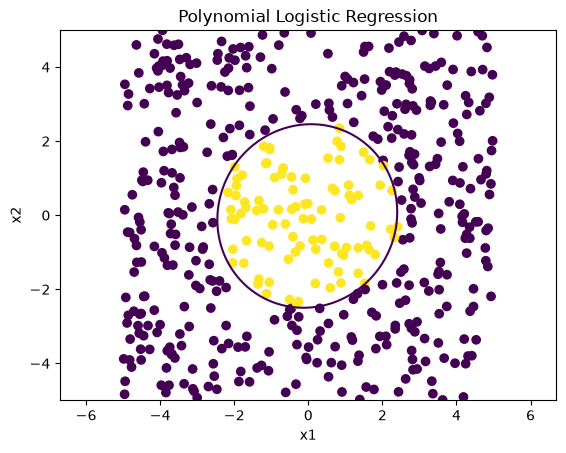

In [95]:
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 300)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 300)

X1, X2 = np.meshgrid(x1, x2)

grid = np.column_stack([X1.ravel(), X2.ravel()])

grid_poly = poly.transform(grid)

probability = lgr_poly.predict_proba(grid_poly)[:, 1]
probability = probability.reshape(X1.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")

plt.contour(X1, X2, probability, levels=[0.5])

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Polynomial Logistic Regression")
plt.axis("equal")
plt.show()


In [96]:
for feature, coef in zip(poly.get_feature_names_out(), lgr_poly.coef_[0]):
    print(feature, coef)


1 9.715603316751056e-05
x0 -0.10896313381870498
x1 -0.07668645818076775
x0^2 -2.0273045681472914
x0 x1 0.16557602853249687
x1^2 -1.9467658689799618


In [105]:
# ((-2.0273045681472914) ** 2 + (-1.9467658689799618) ** 2) - 6.25


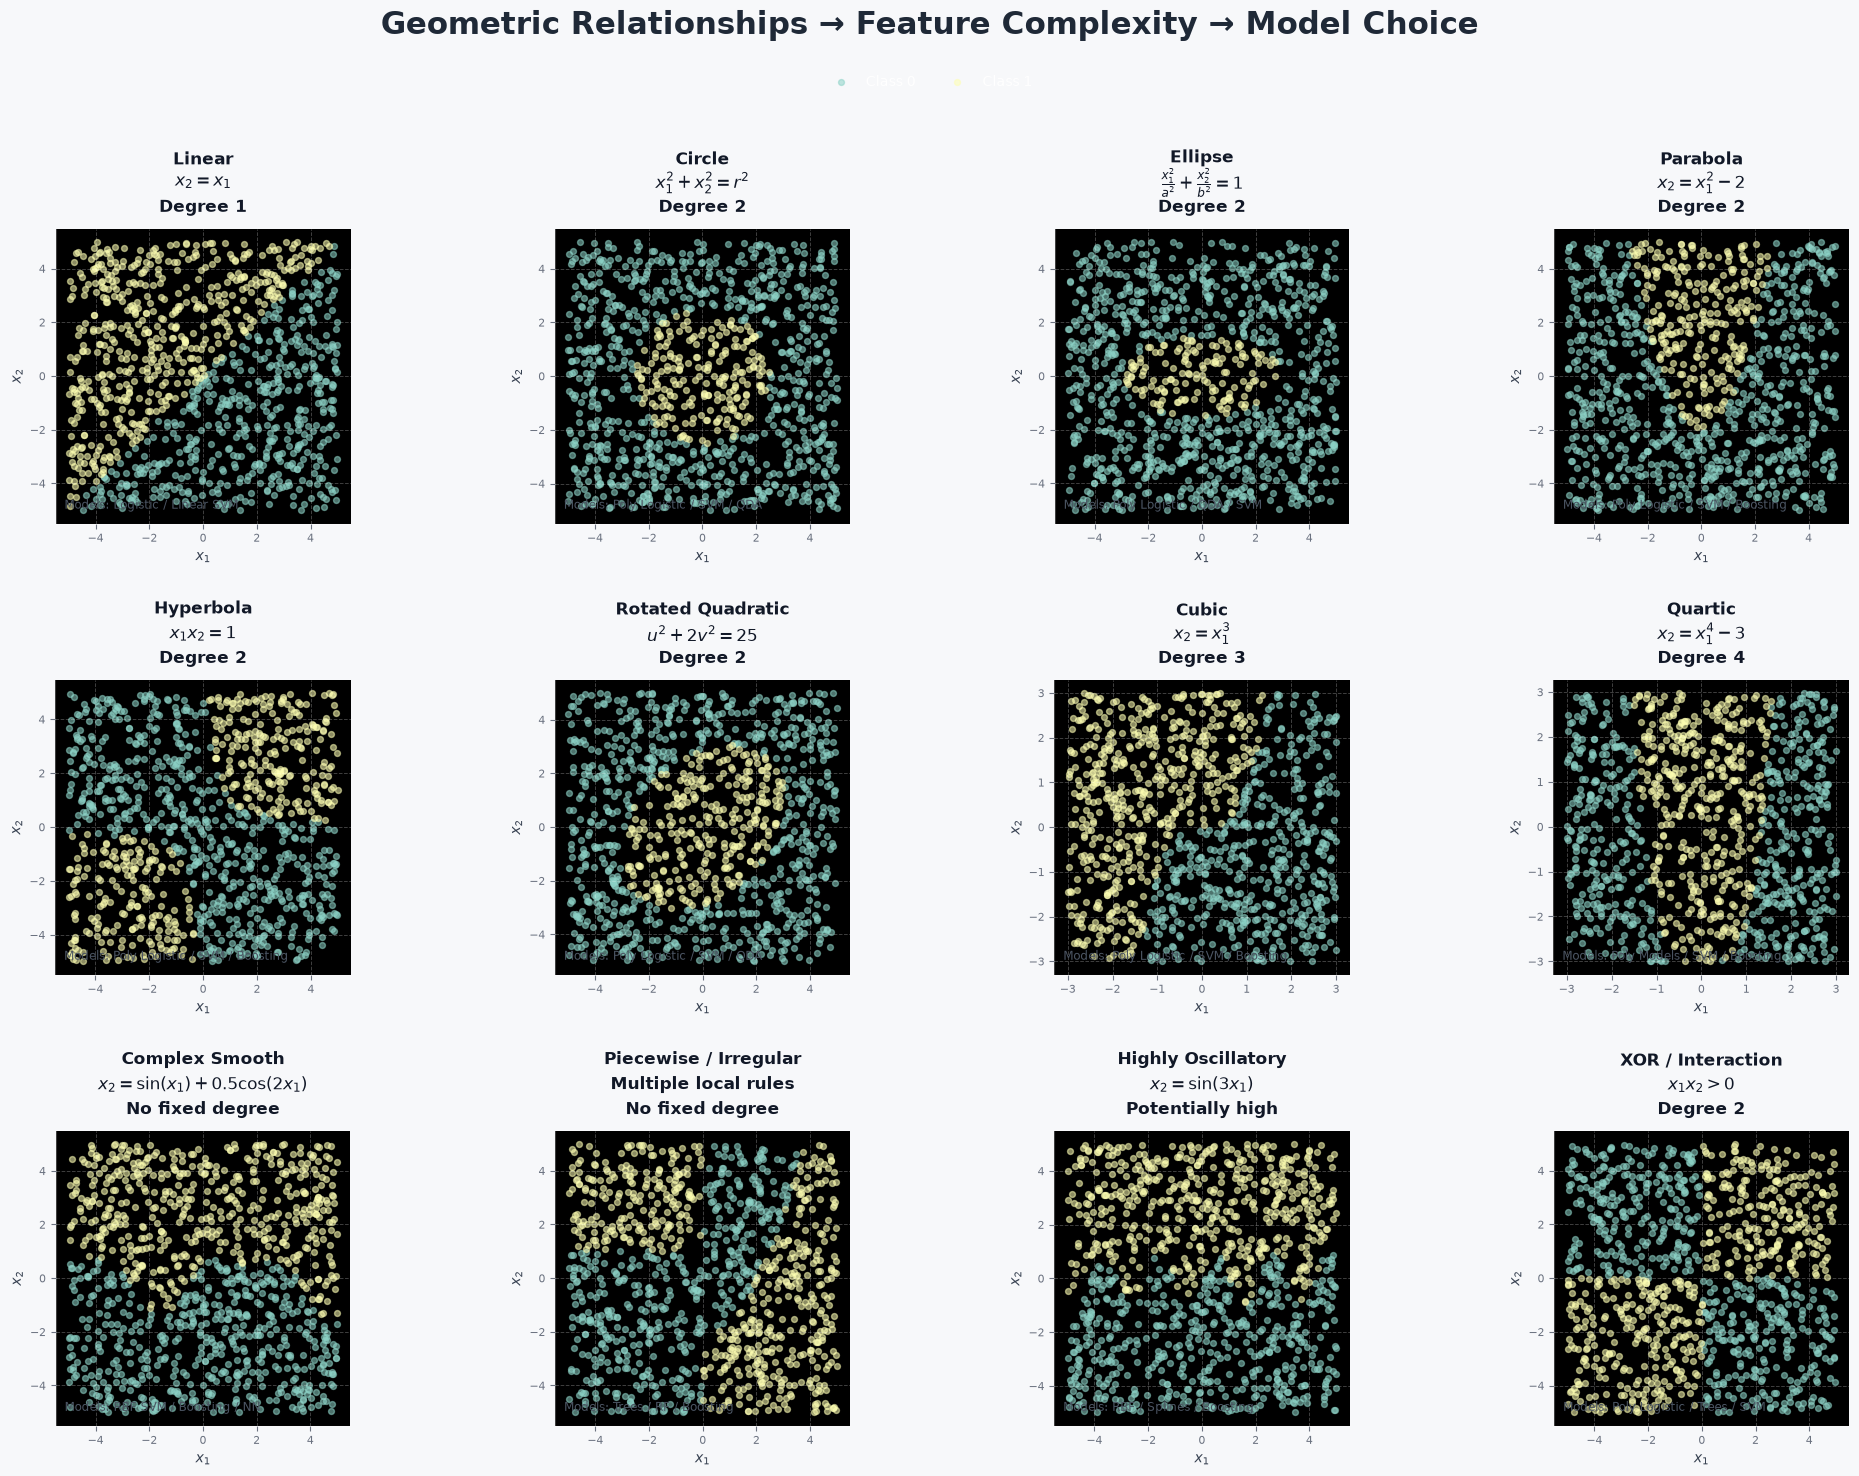

In [113]:
# ---------------------------------------------------------
# LIGHT THEME PLOT
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 4, figsize=(20, 15), facecolor="#F7F8FA")

fig.suptitle(
    "Geometric Relationships → Feature Complexity → Model Choice",
    fontsize=22,
    fontweight="bold",
    color="#1F2937",
    y=0.98,
)

for ax, (name, (X, y, equation, degree, algorithms)) in zip(
    axes.flatten(), data.items()
):
    # -------------------------
    # Plot classes
    # -------------------------
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=18, alpha=0.55, label="Class 0")

    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=18, alpha=0.55, label="Class 1")

    # -------------------------
    # Heading
    # -------------------------
    ax.set_title(
        f"{name}\n{equation}\n{degree}",
        fontsize=12,
        fontweight="bold",
        color="#111827",
        pad=12,
        linespacing=1.5,
    )

    # -------------------------
    # Algorithm recommendation
    # -------------------------
    ax.text(
        0.03,
        0.04,
        f"Models: {algorithms}",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#4B5563",
        verticalalignment="bottom",
    )

    # -------------------------
    # Axes
    # -------------------------
    ax.set_xlabel("$x_1$", fontsize=10, color="#374151")

    ax.set_ylabel("$x_2$", fontsize=10, color="#374151")

    # -------------------------
    # Grid
    # -------------------------
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.25)

    # Keep geometric shapes proportional
    ax.set_aspect("equal")

    # -------------------------
    # Clean borders
    # -------------------------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

    ax.tick_params(colors="#6B7280", labelsize=8)


# ---------------------------------------------------------
# Global legend
# ---------------------------------------------------------

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False,
    fontsize=10,
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=2.5, w_pad=2)

plt.show()
